# Multiple Linear Regression Analysis

## Predicting Toyota Corolla Car Prices

### Objective

The objective of this analysis is to build Multiple Linear Regression models to predict the price of Toyota Corolla cars based on various vehicle characteristics such as Age, Kilometers Driven, Horsepower, Fuel Type, Weight, and other relevant features.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Data Cleaning and Preprocessing
- Multicollinearity Analysis using VIF
- Building Multiple Linear Regression Models
- Comparing a minimum of three MLR models
- Ridge Regression
- Lasso Regression
- Model Evaluation and Comparison

## 1. Importing Required Libraries

The following libraries are used for data manipulation, visualization, statistical analysis, and building regression models.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats

## 2. Loading the Dataset

The Toyota Corolla dataset is loaded into a Pandas DataFrame for further analysis.

In [2]:
# Use the raw GitHub URL to read CSV files directly into Pandas
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/59d78e569aa27b00598ca448684244bb53ce8203/7.%20MLR/data/ToyotaCorolla%20-%20MLR.csv"
df = pd.read_csv(url)

### Preview of the Dataset

The first few rows of the dataset are displayed to understand the structure and values of the variables.

In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


## 3. Initial Data Understanding

Before performing any analysis, the dataset is examined to understand its structure, variables, data types, and sample records.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


### Dataset Dimensions

The shape and size of the dataset are checked to determine the number of observations, features, and total elements.

In [5]:
print("Shape : ",df.shape)
print("Size : ", df.size)

Shape :  (1436, 11)
Size :  15796


### Observation

The dataset initially contains 1436 observations and 11 variables. These include the target variable, Price, along with numerical and categorical predictor variables.

## 4. Data Cleaning

### Checking for Missing Values

Missing values can affect regression analysis and model performance. Therefore, the dataset is checked for null values.

In [6]:
print("No.of Null Values : ",df.isnull().sum())

No.of Null Values :  Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


### Observation

No missing values were found in the dataset. Therefore, no missing value imputation or removal was required.

### Checking for Duplicate Records

Duplicate observations can bias the analysis and model. Therefore, the dataset is checked for duplicate rows.

In [7]:
print("No.of Duplicate values :  ",df.duplicated().sum())

No.of Duplicate values :   1


### Observation

One duplicate record was identified in the dataset. Duplicate records can unnecessarily influence the regression model; therefore, the duplicate observation will be removed.

In [8]:
df.drop_duplicates(inplace=True)
print("No.of Duplicate values after removal :  ",df.duplicated().sum())

No.of Duplicate values after removal :   0


### Result

After removing the duplicate record, the dataset contains 1435 unique observations.

## 5. Descriptive Statistical Analysis

Descriptive statistics are used to understand the central tendency, spread, minimum, maximum, and distribution of numerical variables.

In [9]:
print(df.describe())

              Price    Age_08_04             KM           HP    Automatic  \
count   1435.000000  1435.000000    1435.000000  1435.000000  1435.000000   
mean   10720.915679    55.980488   68571.782578   101.491986     0.055749   
std     3608.732978    18.563312   37491.094553    14.981408     0.229517   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63451.000000   110.000000     0.000000   
75%    11950.000000    70.000000   87041.500000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                 cc        Doors  Cylinders        Gears       Weight  
count   1435.000000  1435.000000     1435.0  1435.000000  1435.000000  
mean    1576.560976     4.032753        4.0     5.026481  1072.287108  
std      424.387533     0.952667        0.0     0.188575    52.251882  
min     1300.00000

### Key Observations

- The average car price is approximately 10,721 Euros.
- The median price is approximately 9,900 Euros.
- The age of the vehicles ranges from 1 to 80 months.
- The accumulated kilometers range from 1 KM to 243,000 KM.
- Most vehicles are non-automatic.
- Horsepower ranges from 69 to 192.
- Vehicle weight ranges from 1000 KG to 1615 KG.

The large range of variables such as KM, Age, and Weight indicates that feature scaling may be useful when applying regularization techniques such as Ridge and Lasso Regression.

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of variables, identify potential outliers, and examine relationships between the features and the target variable.

In [10]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

### Boxplot Analysis

Boxplots are used to identify the spread of numerical variables and detect potential outliers.

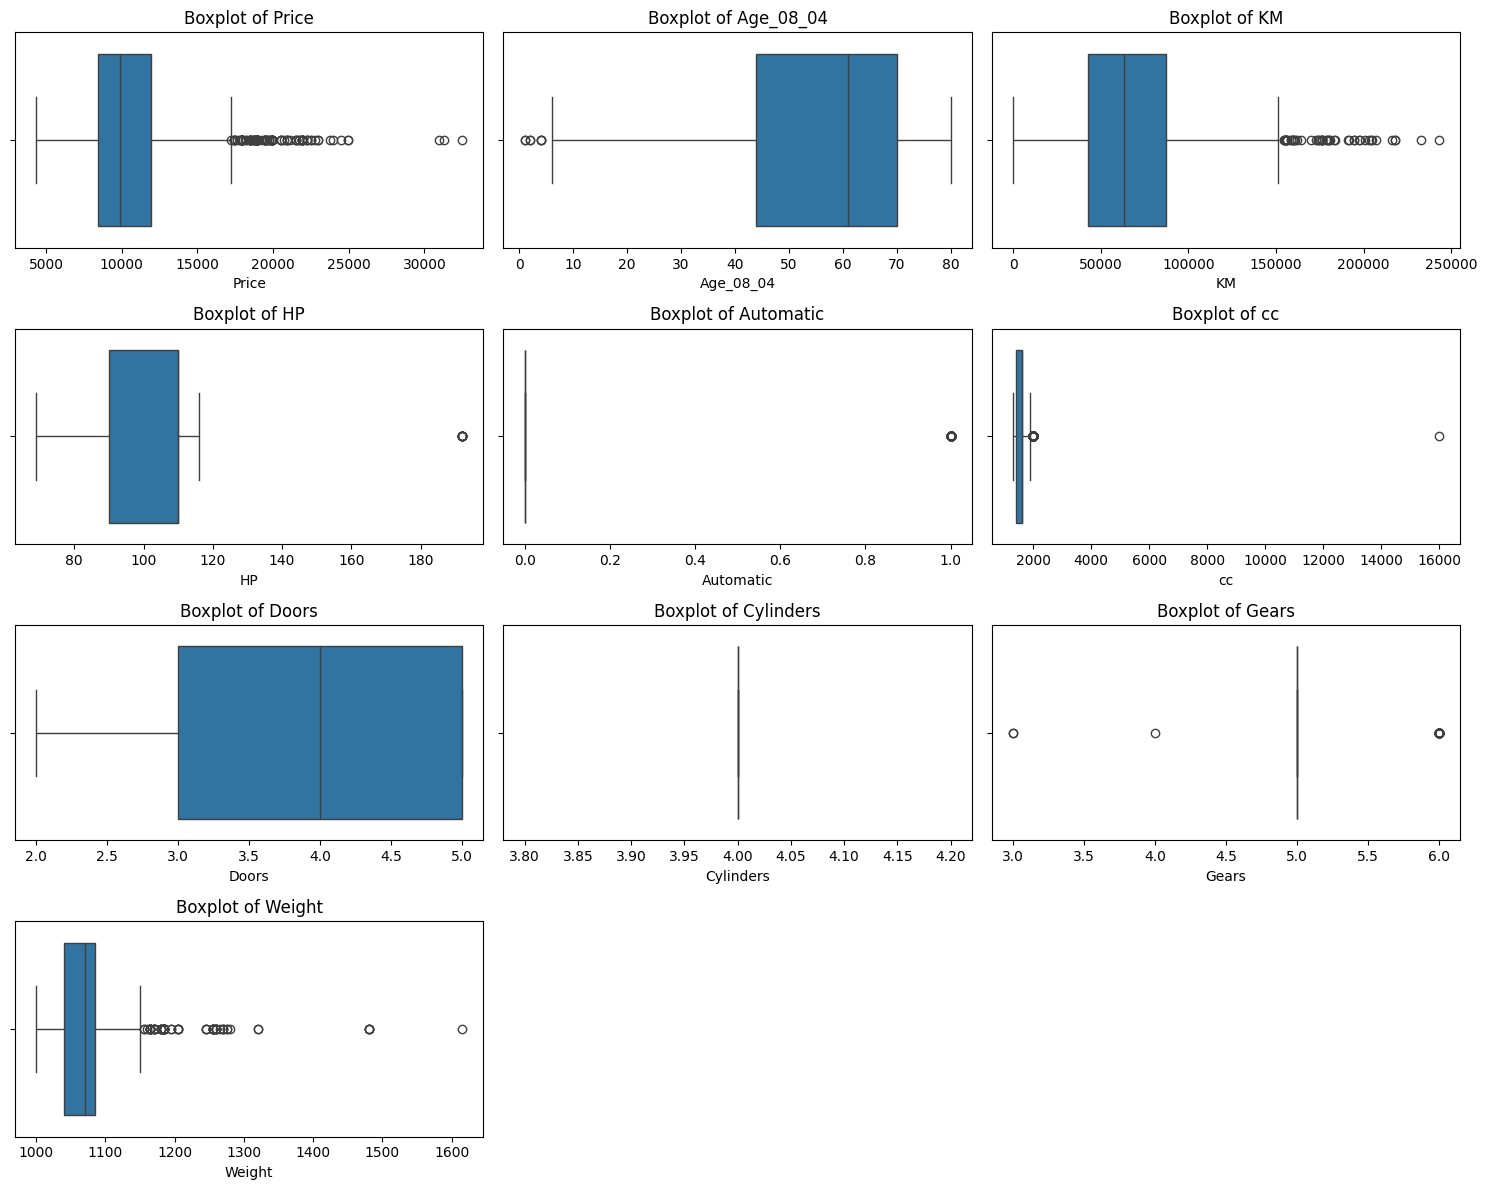

In [11]:
# Select numerical columns for boxplots
num_cols = df.select_dtypes(include=np.number).columns

fig, ax = plt.subplots(4, 3, figsize=(15, 12))

for axis, col in zip(ax.flat, num_cols):
    sns.boxplot(data=df, x=col, ax=axis)
    axis.set_title(f"Boxplot of {col}")

# Remove unused subplots
for axis in ax.flat[len(num_cols):]:
    axis.remove()

plt.tight_layout()
plt.show()

### Boxplot Interpretation

The boxplots were used to identify the spread and potential outliers in the numerical variables. Variables such as Price, KM, HP, and cc show observations that may lie far from the central distribution. These extreme values are retained because they may represent genuine vehicle characteristics rather than data-entry errors.

### Histogram Analysis

Histograms are used to identify the frequency of values.

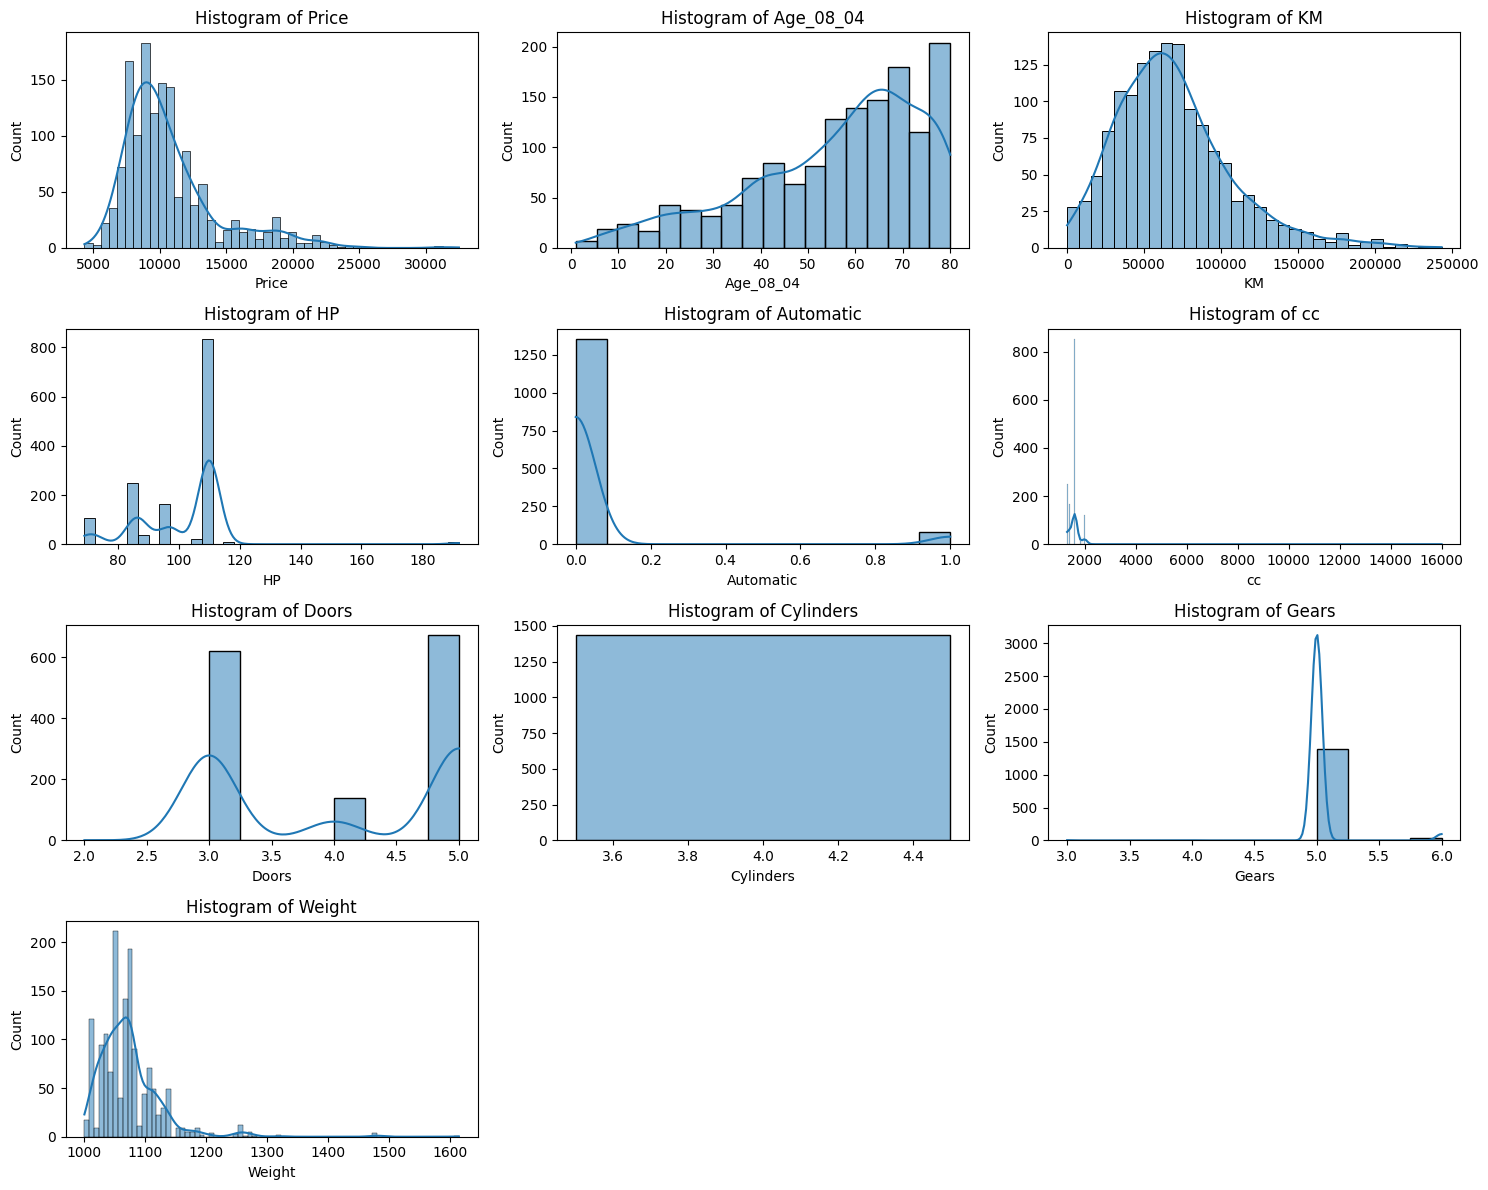

In [12]:
# Select numerical columns for histograms
num_cols = df.select_dtypes(include=np.number).columns

fig, ax = plt.subplots(4, 3, figsize=(15, 12))

for axis, col in zip(ax.flat, num_cols):
    sns.histplot(data=df, x=col, ax=axis, kde=True)
    axis.set_title(f"Histogram of {col}")

# Remove unused subplots
for axis in ax.flat[len(num_cols):]:
    axis.remove()

plt.tight_layout()
plt.show()

### Histogram Interpretation

The histograms show the distribution of the numerical variables. Some variables, particularly KM, show skewness due to the presence of vehicles with very high accumulated kilometers. Price also shows variation across a wide range of values. These distributions provide useful insights into the characteristics of the dataset and possible extreme observations.

### Countplot Analysis

Countplots are used to identify the frequency of values for categorical and discrete columns.

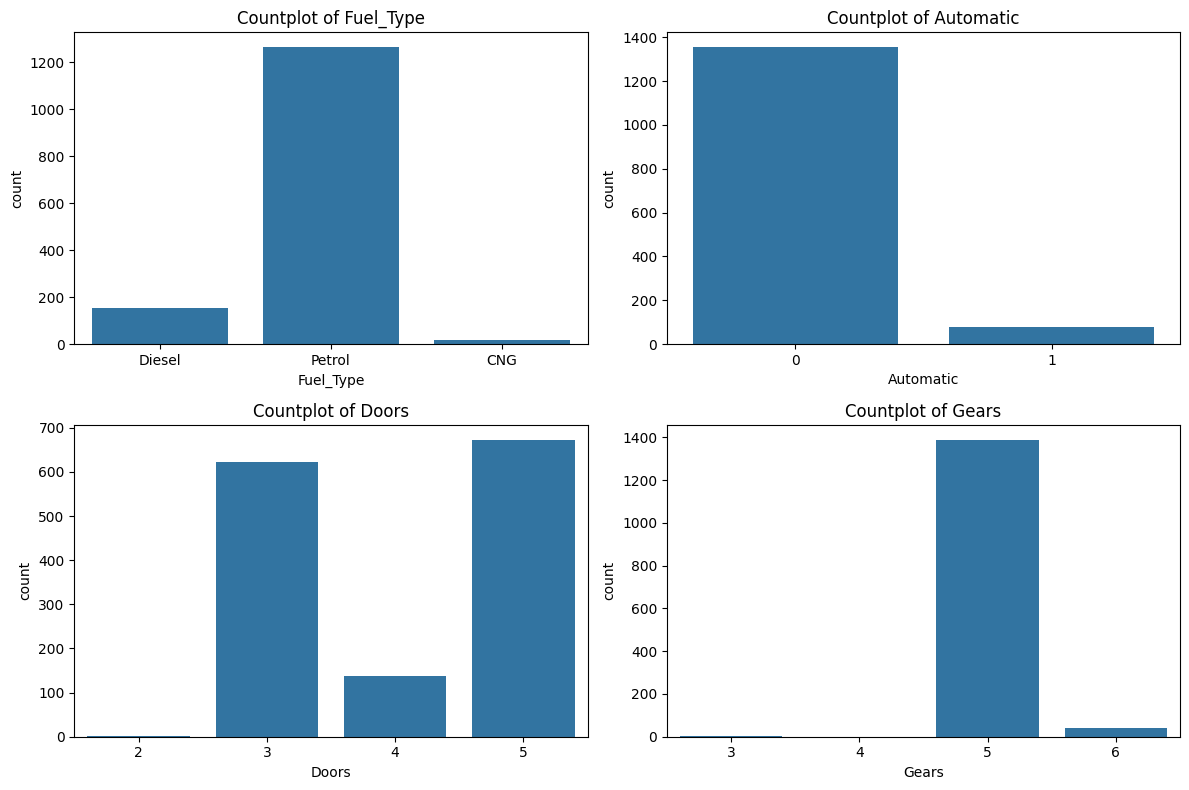

In [13]:
# Select categorical and discrete variables
c_cols = ["Fuel_Type", "Automatic", "Doors", "Gears"]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for axis, col in zip(ax.flat, c_cols):
    sns.countplot(data=df, x=col, ax=axis)
    axis.set_title(f"Countplot of {col}")

plt.tight_layout()
plt.show()

### Countplot Interpretation

The countplots show the frequency distribution of categorical and discrete variables. Most vehicles in the dataset are non-automatic. The distribution of Fuel_Type shows the number of vehicles belonging to Petrol, Diesel, and CNG categories. Doors and Gears also show the frequency of different vehicle configurations.

## Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical variables and identify potential multicollinearity.

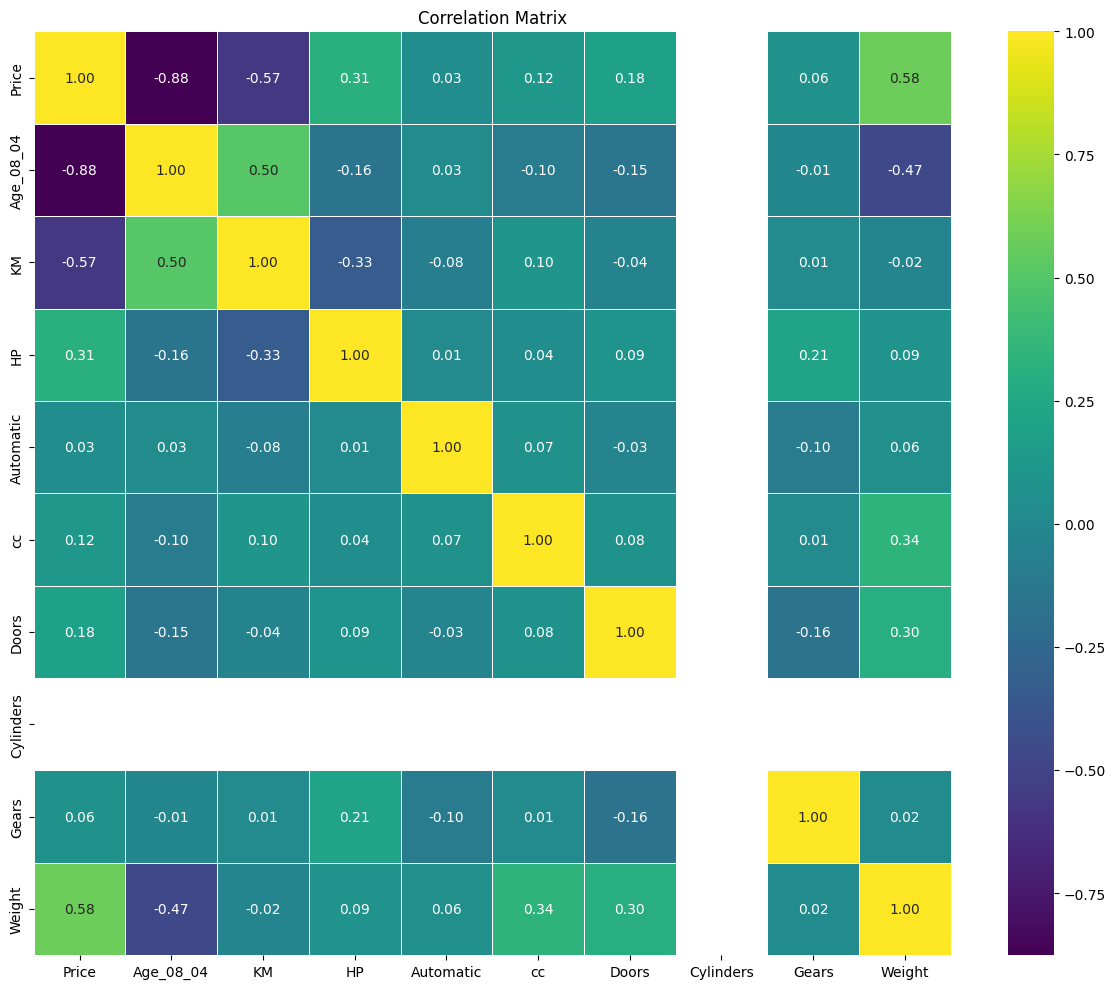

In [14]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation

The correlation analysis helps identify variables that have strong relationships with the target variable, Price. It also provides an initial indication of possible multicollinearity between independent variables, which will be examined further using Variance Inflation Factor (VIF).

## 7. Data Preprocessing

Before building the regression models, the dataset is prepared by removing irrelevant features and converting categorical variables into numerical form.

In [15]:
df["Cylinders"].value_counts()

,count
Cylinders,
4,1435


### Removing the Cylinders Feature

The Cylinders column contains the same value for all observations. Since it has no variation, it cannot provide useful information for predicting car prices. Therefore, this column is removed from the dataset.

In [16]:
df.drop(columns="Cylinders",inplace=True)

### Renaming the Age Column

For better readability, the column `Age_08_04` is renamed to `Age`.

In [17]:
df.rename(columns = {"Age_08_04":"Age"},inplace=True)

### Encoding the Fuel Type Variable

Fuel_Type is a categorical variable containing Petrol, Diesel, and CNG categories. Machine learning models require numerical input; therefore, One-Hot Encoding is applied.

One category is dropped using `drop_first=True` to avoid the dummy variable trap and reduce perfect multicollinearity.

In [18]:
df = pd.get_dummies(df,columns=["Fuel_Type"],drop_first=True,dtype=int)
df.head()

,Price,Age,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


### Observation

After One-Hot Encoding, Fuel_Type is represented using dummy variables. Since `drop_first=True` was used, one category was omitted to avoid the dummy variable trap.

The omitted category is CNG and acts as the reference category:

- Fuel_Type_Diesel = 0 and Fuel_Type_Petrol = 0 → CNG
- Fuel_Type_Diesel = 1 and Fuel_Type_Petrol = 0 → Diesel
- Fuel_Type_Diesel = 0 and Fuel_Type_Petrol = 1 → Petrol

This transformation allows the regression model to use categorical fuel type information numerically.

### Final Dataset Verification

The dataset is checked again after preprocessing to confirm that all variables are numerical and ready for regression modeling.

In [19]:
# Check data types after encoding
print(df.dtypes)

print("\n" + "="*100)

# Display dataset information
df.info()

Price               int64
Age                 int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Gears               int64
Weight              int64
Fuel_Type_Diesel    int64
Fuel_Type_Petrol    int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Price             1435 non-null   int64
 1   Age               1435 non-null   int64
 2   KM                1435 non-null   int64
 3   HP                1435 non-null   int64
 4   Automatic         1435 non-null   int64
 5   cc                1435 non-null   int64
 6   Doors             1435 non-null   int64
 7   Gears             1435 non-null   int64
 8   Weight            1435 non-null   int64
 9   Fuel_Type_Diesel  1435 non-null   int64
 10  Fuel_Type_Petrol  1435 non-null   int64
dtypes: int6

## 8. Multicollinearity Analysis Using VIF

Variance Inflation Factor (VIF) is used to detect multicollinearity among the independent variables.

Multicollinearity occurs when predictor variables are highly correlated with each other. High multicollinearity can make regression coefficients unstable and difficult to interpret.

General guideline:

- VIF ≈ 1 → No multicollinearity
- VIF between 1 and 5 → Low multicollinearity
- VIF between 5 and 10 → Moderate multicollinearity
- VIF greater than 10 → High multicollinearity

In [20]:
# Define independent variables for VIF analysis
X_vif = df.drop(columns=["Price"])

# Add a constant for VIF calculation
X_vif_const = sm.add_constant(X_vif)

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif_const.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

# Remove the constant row and sort values
vif_data = vif_data[vif_data["Feature"] != "const"]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
9,Fuel_Type_Diesel,11.258762
10,Fuel_Type_Petrol,9.652518
8,Weight,3.254342
3,HP,2.300692
2,KM,2.002649
1,Age,1.911952
5,cc,1.223606
6,Doors,1.217072
7,Gears,1.117554
4,Automatic,1.094619


### Observation

The initial VIF analysis shows that some predictors have high VIF values, indicating multicollinearity.

This means that certain independent variables may contain overlapping information. High multicollinearity does not necessarily reduce predictive performance, but it can make regression coefficients unstable and difficult to interpret.

Therefore, different feature combinations will be tested in the regression models.

# 9. Multiple Linear Regression Models

## Model 1: Full Multiple Linear Regression Model

Model 1 uses all available independent variables after preprocessing to establish a baseline performance.

### Feature Selection

Model 1 uses all available predictors after preprocessing. The target variable is Price.

In [21]:
# Model 1 features - all independent variables
X_m1 = df.drop(columns=["Price"])

# Target variable
y = df["Price"]

print("Model 1 - X Shape:", X_m1.shape)
print("Target (y) Shape:", y.shape)

Model 1 - X Shape: (1435, 10)
Target (y) Shape: (1435,)


### Train-Test Split

The dataset is divided into 80% training data and 20% testing data. The training dataset is used to build the model, while the testing dataset is used to evaluate how well the model performs on unseen data.

In [22]:
# Split Model 1 data into training and testing sets
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train_m1.shape)
print("X_test shape:", X_test_m1.shape)
print("y_train shape:", y_train_m1.shape)
print("y_test shape:", y_test_m1.shape)

X_train shape: (1148, 10)
X_test shape: (287, 10)
y_train shape: (1148,)
y_test shape: (287,)


### Model Training

The Multiple Linear Regression model is trained using the training dataset. The model learns the relationship between the independent variables and the target variable, Price.

In [23]:
# Create and train the Multiple Linear Regression model
model_1 = LinearRegression()

model_1.fit(X_train_m1, y_train_m1)

LinearRegression()

In [24]:
# Predict car prices using the test dataset
y_pred_m1 = model_1.predict(X_test_m1)

# Display first few actual and predicted values
comparison_m1 = pd.DataFrame({
    "Actual Price": y_test_m1.values,
    "Predicted Price": y_pred_m1
})

comparison_m1.head()

,Actual Price,Predicted Price
0,9950,10807.905356
1,7995,10326.707030
2,7500,9168.774419
3,9950,9347.156265
4,8950,8470.341325


In [25]:
# Calculate evaluation metrics for Model 1

mae_m1 = mean_absolute_error(y_test_m1, y_pred_m1)

mse_m1 = mean_squared_error(y_test_m1, y_pred_m1)

rmse_m1 = np.sqrt(mse_m1)

r2_m1 = r2_score(y_test_m1, y_pred_m1)

# Store results
Metrics_1 = pd.DataFrame({
    "Model": ["Model 1"],
    "Features": ["All 10 Features"],
    "MAE": [mae_m1],
    "MSE": [mse_m1],
    "RMSE": [rmse_m1],
    "R2": [r2_m1]
})

Metrics_1

,Model,Features,MAE,MSE,RMSE,R2
0,Model 1,All 10 Features,986.496688,2.155628e+06,1468.205829,0.820321


Model 1 achieved an R² score of 0.8203, indicating that approximately 82.03% of the variation in car prices is explained by the selected independent variables. The model obtained an MAE of 986.50 and an RMSE of 1468.21, indicating that the predicted prices differ from the actual prices by approximately 987 to 1468 price units on average. Overall, Model 1 demonstrates good predictive performance, although some observations show relatively larger prediction errors.

### Model 1 Performance

Model 1 achieved an R² score of approximately 0.82, indicating that the model explains around 82% of the variation in car prices. The MAE indicates that the predicted price differs from the actual price by approximately 986 Euros on average.

In [26]:
# Display Model 1 coefficients

coefficients_m1 = pd.DataFrame({
    "Feature": X_m1.columns,
    "Coefficient": model_1.coef_
})

coefficients_m1

,Feature,Coefficient
0,Age,-121.229191
1,KM,-0.015997
2,HP,16.075438
3,Automatic,268.822211
4,cc,-0.047109
5,Doors,-88.097164
6,Gears,455.011874
7,Weight,26.361202
8,Fuel_Type_Diesel,-389.683843
9,Fuel_Type_Petrol,1128.933060


In [27]:
print("Intercept:", model_1.intercept_)

Intercept: -14115.237225945792


### Coefficient Interpretation

Each regression coefficient represents the expected change in the predicted Price when the corresponding feature increases by one unit, while keeping all other variables constant.

- A positive coefficient indicates a positive relationship with Price.
- A negative coefficient indicates a negative relationship with Price.

The exact interpretation of each feature depends on the coefficient values obtained from the model.

## Model 2: Multiple Linear Regression Using Selected Features

Based on the analysis and model comparison approach, Model 2 uses four important predictors:

- Age
- KM
- HP
- Weight

This model is designed to determine whether a smaller set of relevant features can achieve better performance than using all available predictors.

In [28]:
# Select features for Model 2

m2_features = ["Age", "KM", "HP", "Weight"]

X_m2 = df[m2_features]

# Target variable remains the same
y = df["Price"]

print("Model 2 - X Shape:", X_m2.shape)
print("Target (y) Shape:", y.shape)

Model 2 - X Shape: (1435, 4)
Target (y) Shape: (1435,)


In [29]:
# Split Model 2 data into training and testing sets

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train_m2.shape)
print("X_test shape:", X_test_m2.shape)

print("y_train shape:", y_train_m2.shape)
print("y_test shape:", y_test_m2.shape)

X_train shape: (1148, 4)
X_test shape: (287, 4)
y_train shape: (1148,)
y_test shape: (287,)


In [30]:
# Create and train Model 2

model_2 = LinearRegression()

model_2.fit(X_train_m2, y_train_m2)

LinearRegression()

In [31]:
# Predict car prices

y_pred_m2 = model_2.predict(X_test_m2)

comparison_m2 = pd.DataFrame({
    "Actual Price": y_test_m2.values,
    "Predicted Price": y_pred_m2
})

comparison_m2.head()

,Actual Price,Predicted Price
0,9950,10243.695766
1,7995,10394.129812
2,7500,9441.818838
3,9950,9495.156261
4,8950,8442.876090


In [32]:
# Calculate Model 2 evaluation metrics

mae_m2 = mean_absolute_error(y_test_m2, y_pred_m2)

mse_m2 = mean_squared_error(y_test_m2, y_pred_m2)

rmse_m2 = np.sqrt(mse_m2)

r2_m2 = r2_score(y_test_m2, y_pred_m2)

Metrics_2 = pd.DataFrame({
    "Model": ["Model 2"],
    "Features": ["Age, KM, HP, Weight"],
    "MAE": [mae_m2],
    "MSE": [mse_m2],
    "RMSE": [rmse_m2],
    "R2": [r2_m2]
})

Metrics_2

,Model,Features,MAE,MSE,RMSE,R2
0,Model 2,"Age, KM, HP, Weight",987.225283,1.934479e+06,1390.855427,0.838755


Model 2 was developed using four important predictors: Age, KM, HP, and Weight. The model achieved an R² score of 0.8388, indicating that approximately 83.88% of the variation in car prices is explained by these four variables. The model obtained an MAE of 987.23 and an RMSE of 1390.86. Compared with Model 1, Model 2 achieved a higher R² score and a lower RMSE while using fewer features. Therefore, Model 2 provides a simpler and better-performing model for predicting car prices.

In [33]:
# Display Model 2 coefficients

coefficients_m2 = pd.DataFrame({
    "Feature": X_m2.columns,
    "Coefficient": model_2.coef_
})

coefficients_m2

,Feature,Coefficient
0,Age,-120.619071
1,KM,-0.020074
2,HP,31.478589
3,Weight,19.847999


In [34]:
print("Intercept:", model_2.intercept_)

Intercept: -5626.020126524485


### Model 2 Coefficient Interpretation

The coefficients show how each selected feature affects the predicted car price while keeping the other features constant.

- **Age:** A negative coefficient indicates that older cars tend to have lower prices.
- **KM:** A negative coefficient indicates that cars with higher accumulated kilometers tend to have lower prices.
- **HP:** A positive coefficient indicates that cars with higher horsepower tend to have higher prices.
- **Weight:** A positive coefficient indicates that heavier vehicles tend to have higher predicted prices.

The magnitude of each coefficient represents the expected change in Price for a one-unit change in that feature, assuming all other features remain constant.

## Model 3: Multiple Linear Regression with Fuel Type Features

Model 3 uses the four predictors from Model 2 and additionally includes the encoded Fuel_Type variables.

This model is built to examine whether adding fuel type information improves the prediction of car prices.

In [35]:
# Select features for Model 3

m3_features = [
    "Age",
    "KM",
    "HP",
    "Weight",
    "Fuel_Type_Diesel",
    "Fuel_Type_Petrol"
]

X_m3 = df[m3_features]

# Target variable remains Price
y = df["Price"]

print("Model 3 - X Shape:", X_m3.shape)
print("Target (y) Shape:", y.shape)

Model 3 - X Shape: (1435, 6)
Target (y) Shape: (1435,)


In [36]:
# Split Model 3 data

X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m3,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
# Create and train Model 3

model_3 = LinearRegression()

model_3.fit(X_train_m3, y_train_m3)

LinearRegression()

In [38]:
# Predict car prices

y_pred_m3 = model_3.predict(X_test_m3)

In [39]:
# Calculate Model 3 evaluation metrics

mae_m3 = mean_absolute_error(y_test_m3, y_pred_m3)

mse_m3 = mean_squared_error(y_test_m3, y_pred_m3)

rmse_m3 = np.sqrt(mse_m3)

r2_m3 = r2_score(y_test_m3, y_pred_m3)

Metrics_3 = pd.DataFrame({
    "Model": ["Model 3"],
    "Features": ["Age, KM, HP, Weight, Fuel Type"],
    "MAE": [mae_m3],
    "MSE": [mse_m3],
    "RMSE": [rmse_m3],
    "R2": [r2_m3]
})

Metrics_3

,Model,Features,MAE,MSE,RMSE,R2
0,Model 3,"Age, KM, HP, Weight, Fuel Type",985.54192,2.157711e+06,1468.915026,0.820148


### Model 3 Performance

Model 3 achieved a slightly lower MAE compared to the other models. However, its RMSE was higher and its R² score was lower than Model 2.

Therefore, Model 2 provides better overall predictive performance despite using fewer features.

In [40]:
# Combine the results of all Multiple Linear Regression models

mlr_comparison = pd.concat(
    [Metrics_1, Metrics_2, Metrics_3],
    ignore_index=True
)

mlr_comparison

,Model,Features,MAE,MSE,RMSE,R2
0,Model 1,All 10 Features,986.496688,2.155628e+06,1468.205829,0.820321
1,Model 2,"Age, KM, HP, Weight",987.225283,1.934479e+06,1390.855427,0.838755
2,Model 3,"Age, KM, HP, Weight, Fuel Type",985.541920,2.157711e+06,1468.915026,0.820148


## Comparison of Multiple Linear Regression Models

Model 2 achieved the highest R² score and the lowest RMSE among the three Multiple Linear Regression models.

Although Model 1 achieved a slightly lower MAE, the difference was very small. Model 2 provides better overall predictive performance while using only four features.

Model 3 showed the weakest performance, indicating that adding Fuel_Type variables did not improve prediction accuracy for this dataset.

## 10. VIF Analysis for Model 2

Model 2 showed the best overall performance among the three Multiple Linear Regression models. Therefore, VIF is calculated again using the selected Model 2 features to check whether multicollinearity is present among these predictors.

In [41]:
# Add constant for VIF calculation
X_m2_const = sm.add_constant(X_m2)

vif_m2 = pd.DataFrame()

vif_m2["Feature"] = X_m2_const.columns

vif_m2["VIF"] = [
    variance_inflation_factor(X_m2_const.values, i)
    for i in range(X_m2_const.shape[1])
]

# Remove constant
vif_m2 = vif_m2[vif_m2["Feature"] != "const"]

vif_m2.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,Age,1.865213
2,KM,1.613482
4,Weight,1.400677
3,HP,1.138294


### Interpretation

The VIF values for the selected Model 2 features are within an acceptable range. This indicates that severe multicollinearity is not present among Age, KM, HP, and Weight.

Therefore, the selected predictors can be used together in the regression model without major concerns regarding multicollinearity.

# 11. Ridge Regression

Ridge Regression is a regularized version of Multiple Linear Regression.

It adds an L2 penalty to the regression model, which helps reduce the effect of large coefficients and can improve model stability when multicollinearity is present.

Feature scaling is performed before applying Ridge Regression because Ridge is sensitive to differences in feature scales.

In [42]:
# Features used for Ridge Regression

X_ridge = df[["Age", "KM", "HP", "Weight"]]

# Target variable
y = df["Price"]

In [43]:
# Split the dataset into training and testing sets

X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(
    X_ridge,
    y,
    test_size=0.20,
    random_state=42
)

### Feature Scaling

The selected features have different ranges and units. For example, KM has values in thousands while Age and HP have much smaller ranges.

Therefore, StandardScaler is used to standardize the features before applying Ridge Regression.

In [44]:
# Create StandardScaler object

scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_ridge_scaled = scaler.fit_transform(X_train_ridge)

# Transform the testing data using the same scaler
X_test_ridge_scaled = scaler.transform(X_test_ridge)

In [45]:
# Create Ridge Regression model

ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train_ridge_scaled, y_train_ridge)

Ridge()

### Ridge Model Training

The Ridge Regression model is trained using standardized training features. The parameter `alpha` controls the strength of regularization.

A larger alpha applies stronger regularization, while a smaller alpha makes the model behave more similarly to ordinary Multiple Linear Regression.

In [46]:
# Predict car prices using the Ridge model

y_pred_ridge = ridge_model.predict(X_test_ridge_scaled)

In [47]:
# Calculate Ridge Regression evaluation metrics

mae_ridge = mean_absolute_error(y_test_ridge, y_pred_ridge)

mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)

rmse_ridge = np.sqrt(mse_ridge)

r2_ridge = r2_score(y_test_ridge, y_pred_ridge)

ridge_results = pd.DataFrame({
    "Model": ["Ridge"],
    "Features": ["Age, KM, HP, Weight"],
    "MAE": [mae_ridge],
    "MSE": [mse_ridge],
    "RMSE": [rmse_ridge],
    "R2": [r2_ridge]
})

ridge_results

,Model,Features,MAE,MSE,RMSE,R2
0,Ridge,"Age, KM, HP, Weight",987.15577,1.934309e+06,1390.794301,0.838769


### Ridge Regression Performance

Ridge Regression achieved performance very similar to Model 2. The R² score and RMSE values show that regularization did not significantly change the predictive performance.

This suggests that the selected Model 2 features already have relatively low multicollinearity and produce a stable regression model.

# 12. Lasso Regression

Lasso Regression is another regularization technique that applies an L1 penalty to the regression model.

Unlike Ridge Regression, Lasso can shrink some coefficients completely to zero. This makes Lasso useful for feature selection because features with coefficients equal to zero can potentially be removed from the model.

### Feature Scaling

Lasso Regression uses the same selected features as Ridge Regression. Therefore, the standardized training and testing datasets created earlier are reused.

In [48]:
# The standardized Model 2 features are reused for Lasso Regression

X_train_lasso_scaled = X_train_ridge_scaled
X_test_lasso_scaled = X_test_ridge_scaled

y_train_lasso = y_train_ridge
y_test_lasso = y_test_ridge

In [49]:
# Create Lasso Regression model

lasso_model = Lasso(alpha=1.0)

# Train the model
lasso_model.fit(X_train_ridge_scaled, y_train_ridge)

Lasso()

In [50]:
# Predict car prices using the Lasso model

y_pred_lasso = lasso_model.predict(X_test_ridge_scaled)

In [51]:
# Calculate Lasso Regression evaluation metrics

mae_lasso = mean_absolute_error(y_test_ridge, y_pred_lasso)

mse_lasso = mean_squared_error(y_test_ridge, y_pred_lasso)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(y_test_ridge, y_pred_lasso)

lasso_results = pd.DataFrame({
    "Model": ["Lasso"],
    "Features": ["Age, KM, HP, Weight"],
    "MAE": [mae_lasso],
    "MSE": [mse_lasso],
    "RMSE": [rmse_lasso],
    "R2": [r2_lasso]
})

lasso_results

,Model,Features,MAE,MSE,RMSE,R2
0,Lasso,"Age, KM, HP, Weight",987.055646,1.933641e+06,1390.554306,0.838825


In [52]:
# Display Lasso coefficients

lasso_coefficients = pd.DataFrame({
    "Feature": ["Age", "KM", "HP", "Weight"],
    "Coefficient": lasso_model.coef_
})

lasso_coefficients

,Feature,Coefficient
0,Age,-2254.781850
1,KM,-757.616788
2,HP,472.457971
3,Weight,1002.868736


### Lasso Coefficient Interpretation

The coefficients are based on standardized features. Therefore, their exact values should not be interpreted as a one-unit increase in the original variables.

However, the signs of the coefficients show the direction of the relationship:

- **Age:** Negative relationship with Price.
- **KM:** Negative relationship with Price.
- **HP:** Positive relationship with Price.
- **Weight:** Positive relationship with Price.

None of the coefficients were reduced to zero. Therefore, with the selected alpha value, Lasso Regression did not eliminate any of the four selected features.

# 13. Final Model Comparison

All Multiple Linear Regression and regularized regression models are compared using MAE, MSE, RMSE, and R².

In [53]:
# Combine results from all models

final_results = pd.concat(
    [
        Metrics_1,
        Metrics_2,
        Metrics_3,
        ridge_results,
        lasso_results
    ],
    ignore_index=True
)

final_results

,Model,Features,MAE,MSE,RMSE,R2
0,Model 1,All 10 Features,986.496688,2.155628e+06,1468.205829,0.820321
1,Model 2,"Age, KM, HP, Weight",987.225283,1.934479e+06,1390.855427,0.838755
2,Model 3,"Age, KM, HP, Weight, Fuel Type",985.541920,2.157711e+06,1468.915026,0.820148
3,Ridge,"Age, KM, HP, Weight",987.155770,1.934309e+06,1390.794301,0.838769
4,Lasso,"Age, KM, HP, Weight",987.055646,1.933641e+06,1390.554306,0.838825


### Final Model Comparison Interpretation

Lasso Regression achieved the best overall performance based on the highest R² score and the lowest MSE and RMSE.

Model 1 achieved the lowest MAE, but the difference compared with Lasso Regression was extremely small.

Model 2, Ridge, and Lasso Regression produced very similar results, indicating that the selected features Age, KM, HP, and Weight provide strong predictive information for estimating car prices.

Model 3 performed the worst, showing that adding Fuel_Type variables did not improve prediction performance.

# 14. Model Performance Visualization

The following visualizations compare the performance of all models.

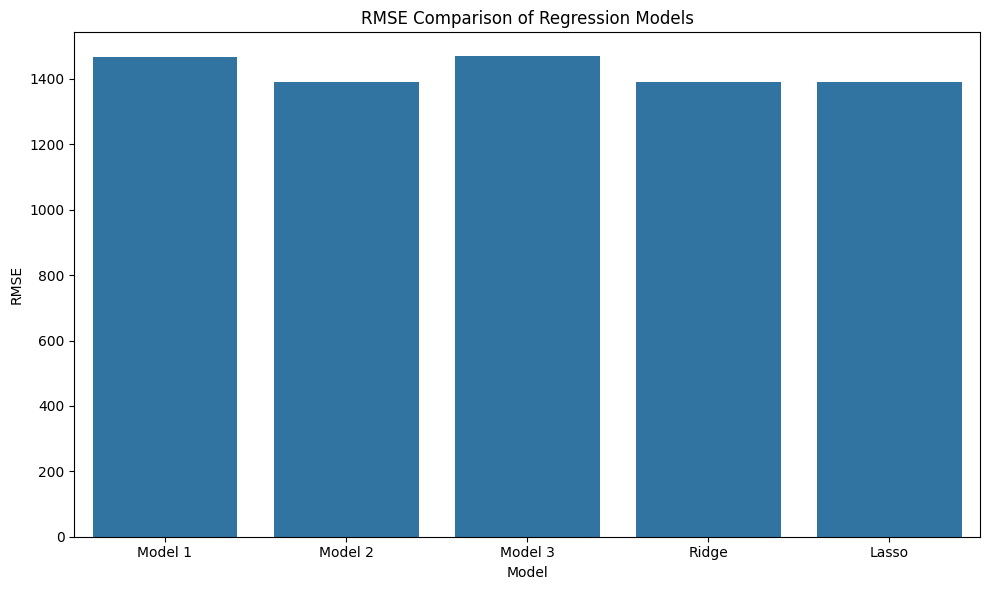

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(data=final_results, x="Model", y="RMSE")

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

### RMSE Interpretation

Lasso Regression achieved the lowest RMSE, indicating the lowest overall prediction error among the models. Ridge Regression and Model 2 performed very similarly.

Model 3 had the highest RMSE, indicating comparatively larger prediction errors.

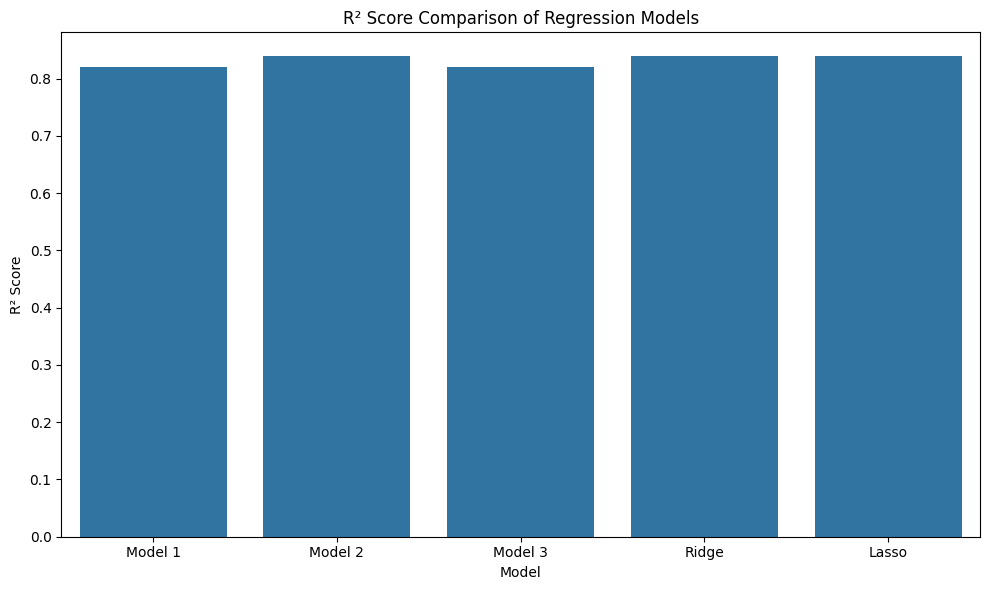

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(data=final_results, x="Model", y="R2")

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

### R² Interpretation

Lasso Regression achieved the highest R² score, followed closely by Ridge Regression and Model 2.

The differences between these three models are very small, indicating similar predictive performance. Model 3 achieved the lowest R² score.

# 15. Residual Analysis

Residual analysis is used to examine the difference between the actual and predicted values.

Residual = Actual Value − Predicted Value

Residual plots help evaluate whether the assumptions of regression are reasonably satisfied.

In [56]:
# Calculate residuals for the Lasso model

residuals = y_test_ridge - y_pred_lasso

# Display the first few residual values
residuals.head()

,Price
753,-293.671058
858,-2398.620032
630,-1943.175264
1412,455.324596
975,505.828664


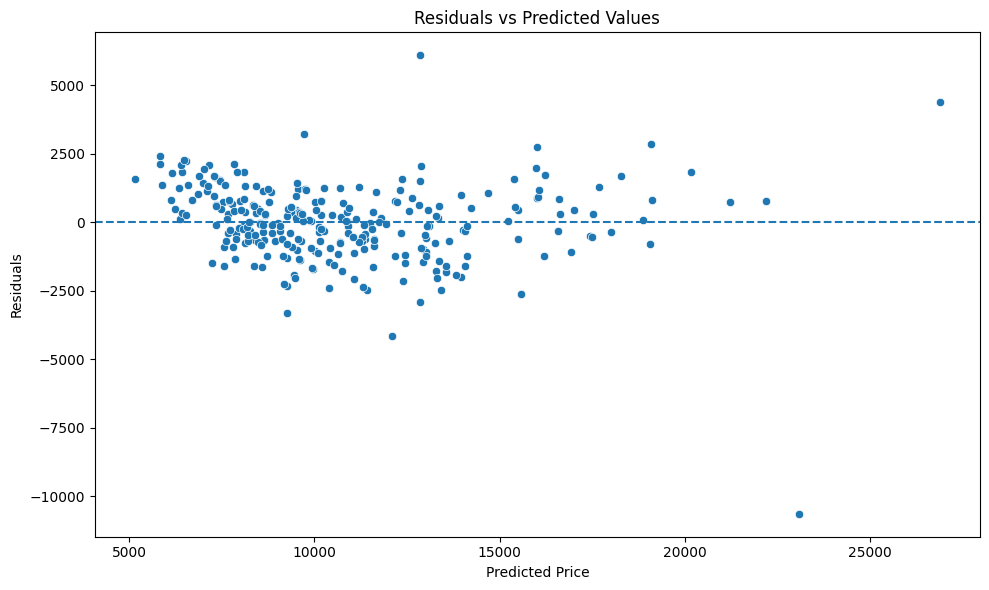

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_lasso,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

### Interpretation

Ideally, residuals should be randomly scattered around the horizontal zero line.

A random pattern suggests that the linear regression model is reasonably capturing the relationship between the predictors and the target variable.

Clear patterns, curves, or systematic structures in the residual plot may indicate that the linear relationship assumption is not fully satisfied.

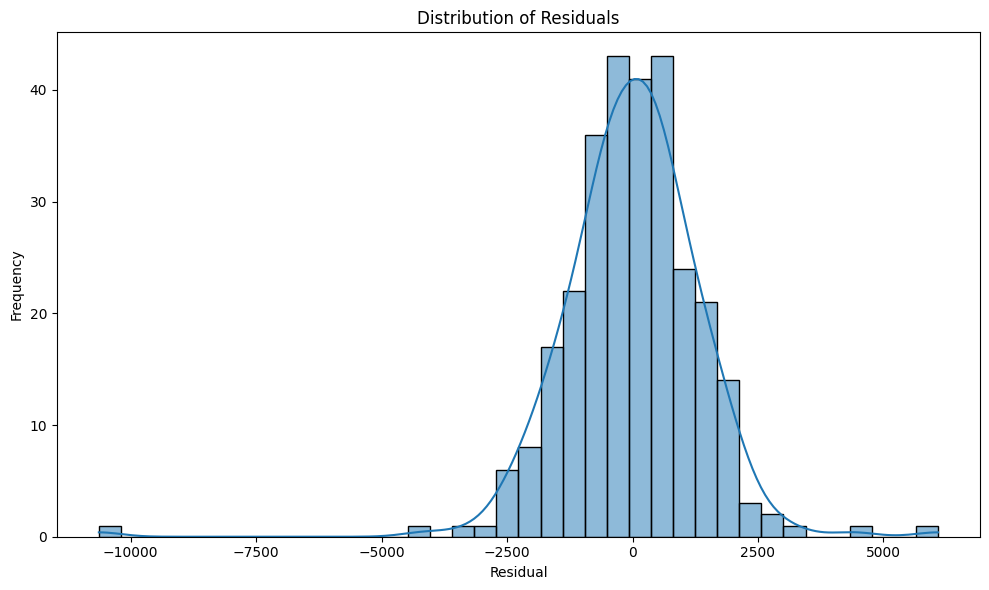

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of residuals is examined to determine whether they are approximately normally distributed.

For linear regression, residuals are ideally expected to follow an approximately normal distribution. Minor deviations from normality are common in real-world datasets and may not necessarily invalidate the predictive usefulness of the model.

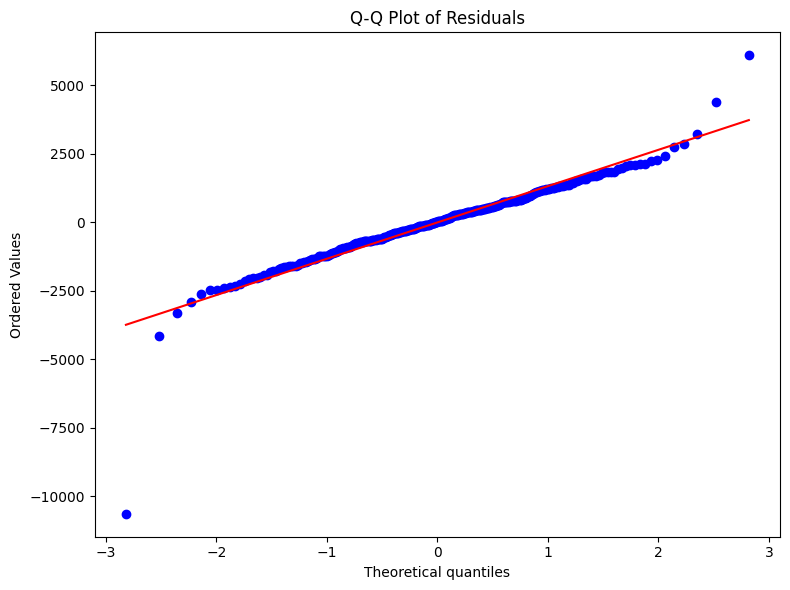

In [59]:
plt.figure(figsize=(8, 6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### Interpretation

In a Q-Q plot, residuals that follow an approximately normal distribution should generally fall close to the reference line.

Large deviations from the line, especially at the ends, may indicate departures from normality or the presence of extreme observations.

# 16. Multiple Linear Regression Assumptions

Multiple Linear Regression is based on several assumptions. These assumptions are examined to understand the reliability and limitations of the regression analysis.

### 1. Linearity

The relationship between the independent variables and the target variable should be approximately linear.

Implication:
If the relationship is strongly non-linear, a linear regression model may not capture the underlying relationship effectively, which can reduce prediction accuracy.

### 2. Independence of Observations

The observations should be independent of one another.

Implication:
If observations are dependent, the regression estimates may become biased or unreliable. In this dataset, each row represents a separate vehicle, so independence is assumed.

### 3. Homoscedasticity

The variance of residuals should remain approximately constant across different predicted values.

This assumption is examined using the Residuals vs Predicted Values plot.

Implication:
If the spread of residuals changes significantly across predicted values, heteroscedasticity may be present. This can affect the reliability of regression coefficient estimates and statistical inference.

### 4. Normality of Residuals

The residuals should be approximately normally distributed.

This assumption is examined using the histogram and Q-Q plot of residuals.

Implication:
Significant departures from normality can affect statistical inference, particularly confidence intervals and hypothesis testing. However, minor deviations may still allow the model to perform well for prediction.

### 5. No Severe Multicollinearity

Independent variables should not be excessively correlated with one another.

VIF analysis was performed to identify multicollinearity among the predictors.

Implication:
Severe multicollinearity can make regression coefficients unstable and difficult to interpret. The selected Model 2 features showed acceptable VIF values, supporting the use of these predictors together.

### 6. No Extreme Influential Outliers

Regression models can be sensitive to extreme observations that strongly influence the fitted regression line.

The boxplots and residual analysis were used to identify potential extreme observations.

Implication:
Extreme influential observations can distort regression coefficients and reduce the generalizability of the model. Potential outliers should therefore be examined carefully rather than automatically removed.

# 17. Actual vs Predicted Price

This visualization compares the actual car prices with the prices predicted by the best-performing regression model.

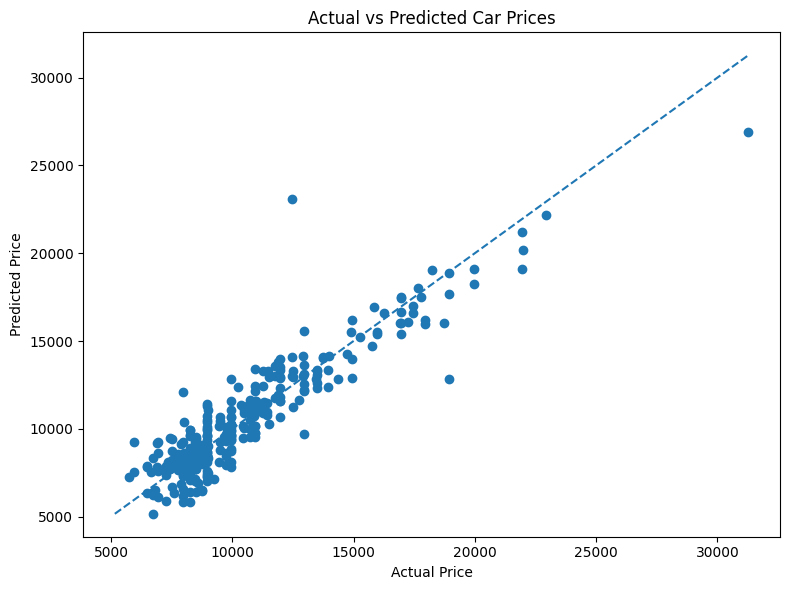

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_ridge, y_pred_lasso)

# Create reference line
min_value = min(y_test_ridge.min(), y_pred_lasso.min())
max_value = max(y_test_ridge.max(), y_pred_lasso.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

### Interpretation

The diagonal reference line represents perfect predictions.

Points closer to the reference line indicate predictions that are closer to the actual car prices. The scatter around the line represents prediction error.

# 18. Interview Questions

## 1. What is Normalization and Standardization, and how are they helpful?

### Normalization

Normalization is a feature scaling technique that transforms values into a fixed range, usually between 0 and 1.

The Min-Max Normalization formula is:

X' = (X - Xmin) / (Xmax - Xmin)

Normalization is useful when features have different ranges and when the distribution of the data does not necessarily need to be centered around zero.

---

### Standardization

Standardization transforms the data so that it has:

- Mean = 0
- Standard Deviation = 1

The formula is:

Z = (X - μ) / σ

Standardization is particularly useful for algorithms that are sensitive to feature scales, such as Ridge Regression and Lasso Regression.

---

### How They Are Helpful

Feature scaling helps ensure that variables with larger numerical ranges do not dominate variables with smaller ranges.

For example:

- KM may contain values in the hundreds of thousands.
- Age may contain values below 100.
- HP may contain values around 70–200.

Without scaling, regularization methods such as Ridge and Lasso can be disproportionately affected by the magnitude of different variables.

Therefore, StandardScaler was applied before Ridge and Lasso Regression in this analysis.

## 2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

Multicollinearity occurs when two or more independent variables are highly correlated with each other.

Several techniques can be used to address multicollinearity:

### 1. Remove Highly Correlated Variables

If two predictors provide very similar information, one of them can be removed.

### 2. Use Variance Inflation Factor (VIF)

VIF helps identify variables that have high multicollinearity.

Variables with very high VIF values can be investigated and potentially removed.

### 3. Feature Selection

A smaller set of relevant predictors can be selected based on statistical analysis and model performance.

This approach was used in Model 2 by selecting Age, KM, HP, and Weight.

### 4. Ridge Regression

Ridge Regression applies L2 regularization and reduces the impact of multicollinearity by shrinking coefficient values.

### 5. Lasso Regression

Lasso Regression applies L1 regularization and can shrink some coefficients to zero, effectively performing feature selection.

### 6. Principal Component Analysis (PCA)

Highly correlated variables can be transformed into a smaller number of uncorrelated principal components.

# 19. Final Conclusion

This analysis used Multiple Linear Regression to predict Toyota Corolla prices based on vehicle characteristics.

The dataset was first explored using descriptive statistics and visualizations. Data preprocessing included checking for missing values, removing duplicate records, removing the constant Cylinders feature, renaming the Age variable, and applying One-Hot Encoding to the Fuel_Type variable.

Three Multiple Linear Regression models were developed and evaluated using MAE, MSE, RMSE, and R².

Among the three Multiple Linear Regression models, Model 2, which used Age, KM, HP, and Weight, achieved the best overall performance.

Ridge and Lasso Regression were then applied using the same selected features. Both regularization methods produced performance very similar to Model 2.

Lasso Regression achieved the highest R² score and the lowest RMSE among the tested models, although the differences between Model 2, Ridge, and Lasso were very small.

The final results demonstrate that Age, KM, HP, and Weight are strong predictors of Toyota Corolla prices in this dataset.

Overall, the regression analysis achieved an R² score of approximately 0.84, indicating that the selected model explains approximately 84% of the variation in vehicle prices.